In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

### Noise Schedule + Markov-Chain

In [31]:
def linear_schedule(T, beta_s=1e-4, beta_e=0.02):
    # beta_s ~ beta_e 선형 증가
    return np.linspace(beta_s, beta_e, T)

def quadratic_schedule(T, beta_s=1e-4, beta_e=0.02):
    return np.linspace(beta_s**0.5, beta_e**0.5, T)**2

def sigmoid_schedule(T, beta_s=1e-4, beta_e=0.02):
    x = np.linspace(-6, 6, T)
    return (1 / (1+np.exp(-x))) * (beta_e - beta_s) + beta_s

def forward_markov(x0, beta_sch, save_steps):
    results = {0: x0}
    x = x0

    for t_idx, beta in enumerate(beta_sch):
        t = t_idx + 1
        eps = np.random.randn(*x.shape)
        x = np.sqrt(1.0 - beta)*x + np.sqrt(beta)*eps

        if t in save_steps:
            results[t] = x.copy()

    return results

In [32]:
from sklearn.datasets import make_swiss_roll

# Swiss roll 데이터 생성 (2D projection)
n_samples = 1000
data, _ = make_swiss_roll(n_samples, noise=0.1)
x0 = data[:, [0, 2]]  # (N, 2)
x0 = (x0 - x0.mean(0)) / x0.std(0)  # 정규화

T = 1000
save_steps = {0, 100, 200, 400, 600, 800, 1000}
res = forward_markov(x0, linear_schedule(T), save_steps)

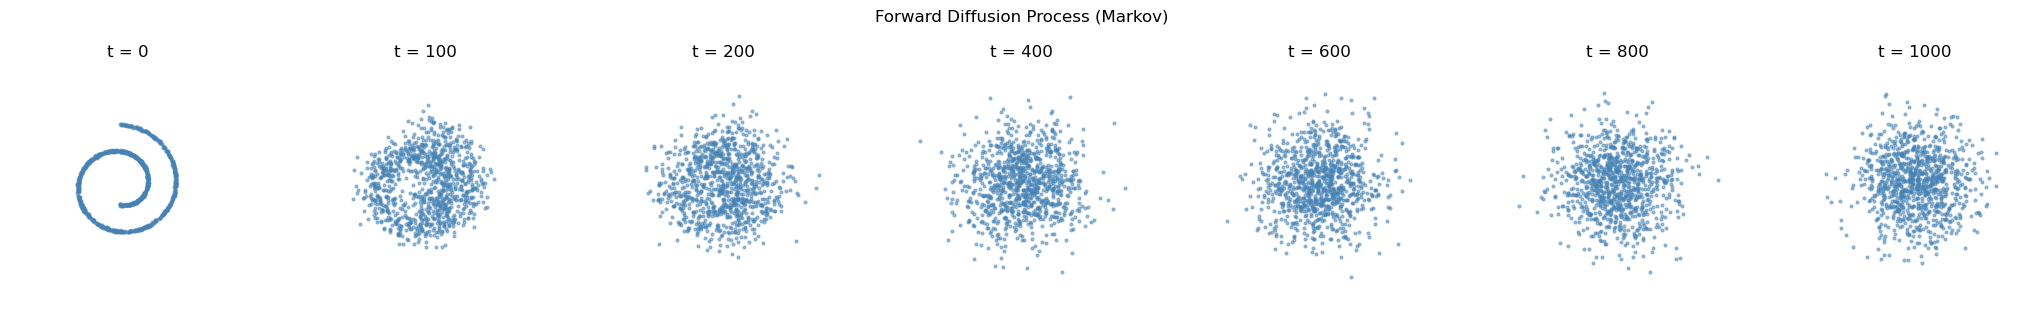

In [33]:
steps = sorted(res.keys())
fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))

for ax, t in zip(axes, steps):
    pts = res[t]
    ax.scatter(pts[:, 0], pts[:, 1], s=4, alpha=0.5, c='steelblue')
    ax.set_title(f"t = {t}")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.axis('off')

fig.suptitle("Forward Diffusion Process (Markov)", y=1.02)
plt.tight_layout()
plt.show()

### SDE
$$
dx = -\frac{1}{2} \beta (t)xdt + \sqrt{\beta(t)}dw
$$
$$
x_{t+1}=\left(1-\frac{1}{2} \beta_t \Delta t \right)x_t + \sqrt{\beta_t \Delta t} \epsilon
$$

In [34]:
def forward_SDE(x0, beta_sch, save_steps, dt=1.0):
    results = {0: x0.copy()}
    x = x0.copy()

    for t_idx, beta in enumerate(beta_sch):
        t = t_idx + 1
        drift = -0.5 * beta * dt * x
        diffusion = np.sqrt(beta * dt) * np.random.randn(*x.shape)
        x = x + drift + diffusion

        if t in save_steps:
            results[t] = x.copy()

    return results

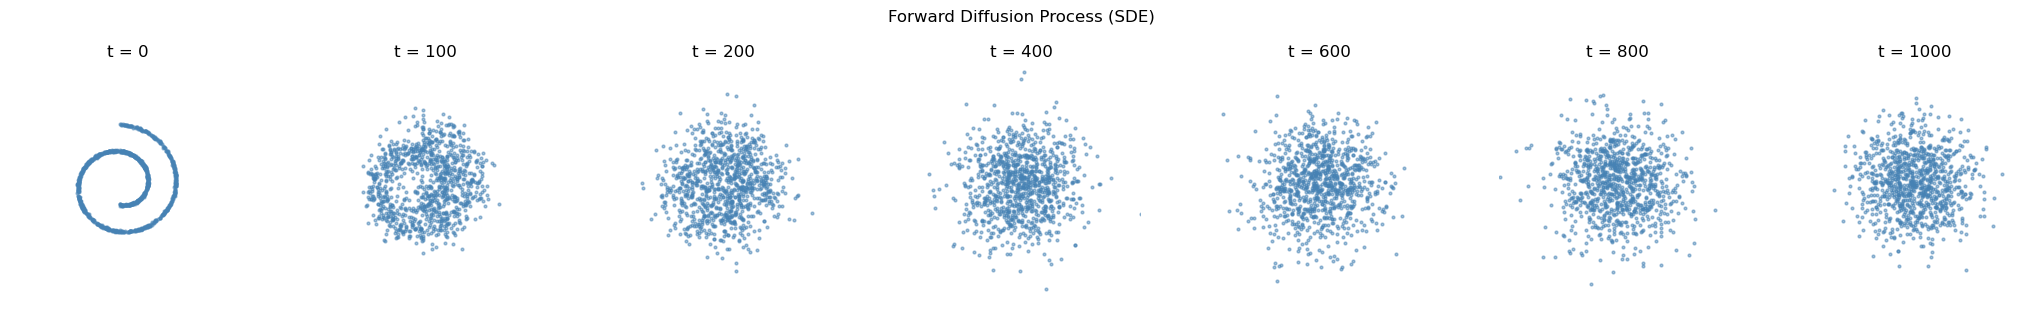

In [35]:
T = 1000
save_steps = {0, 100, 200, 400, 600, 800, 1000}
res = forward_SDE(x0, linear_schedule(T), save_steps)

steps = sorted(res.keys())
fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))

for ax, t in zip(axes, steps):
    pts = res[t]
    ax.scatter(pts[:, 0], pts[:, 1], s=4, alpha=0.5, c="steelblue")
    ax.set_title(f"t = {t}")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.axis("off")

fig.suptitle("Forward Diffusion Process (SDE)", y=1.02)
plt.tight_layout()
plt.show()